# 7주차_데이터 전처리와 파생변수 생성 Ⅱ

- 범주형 변수의 가변수 처리

---

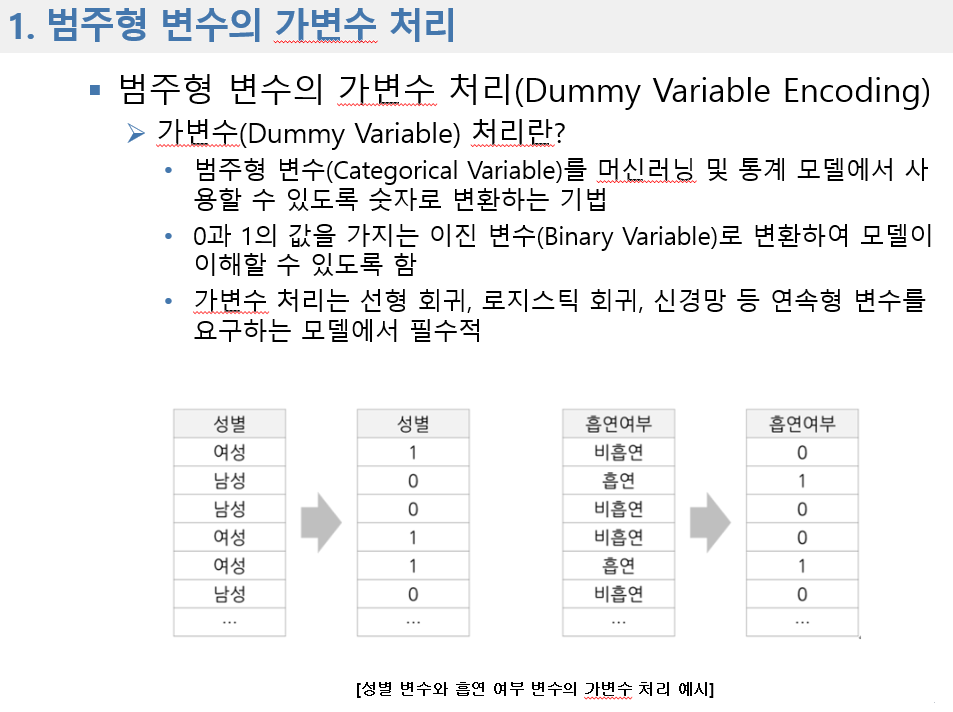

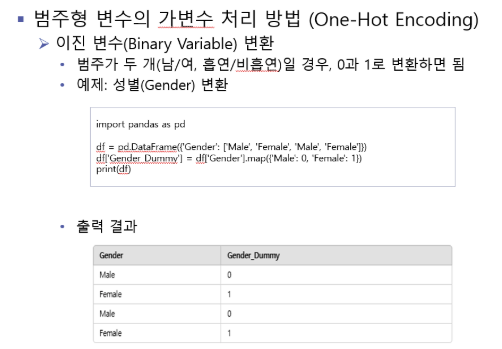

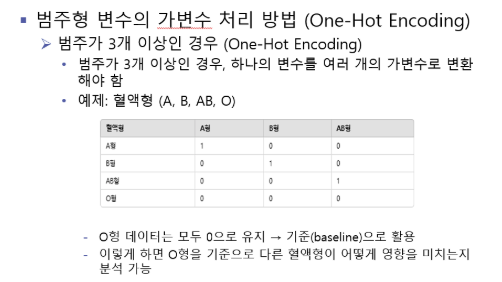

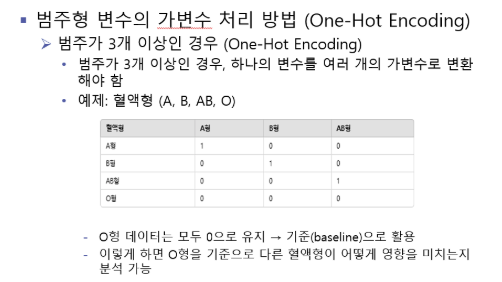

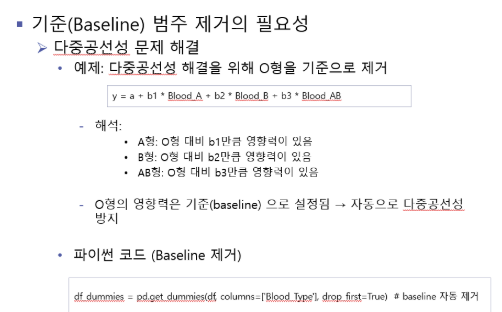

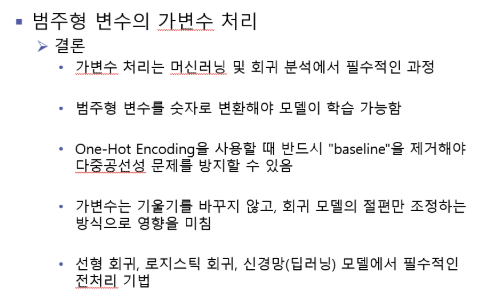

In [ ]:
# 필요한 패키지 설치
import seaborn as sns
# 고급 통계 시각화를 위한 라이브러리 seaborn을 임포트함
# matplotlib 기반으로 더 세련되고 직관적인 시각화를 쉽게 생성할 수 있음

import matplotlib.pyplot as plt
# 그래프 생성을 위한 matplotlib의 핵심 서브모듈인 pyplot을 plt라는 이름으로 임포트함
# 선형 그래프, 막대 그래프, 산점도 등 다양한 시각화 기능을 제공함

import pandas as pd
# 데이터 분석과 처리에 널리 사용되는 pandas 라이브러리를 임포트함
# CSV, Excel 등의 외부 데이터 파일을 불러오거나 DataFrame을 생성해 조작 가능함

plt.rcParams['figure.dpi'] = 300
# 그래프의 해상도를 300 DPI(Dots Per Inch)로 설정함
# 고화질 그래프 출력이 가능하며, 논문 제출이나 인쇄용 자료 작성 시 유용함


In [ ]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/sewonghwang/GPU-CPU-benchmark
df = pd.read_csv("../../main/datasets/GPU_CPU_benchmark.csv")
# 상대 경로를 통해 GPU 및 CPU 벤치마크 데이터를 포함한 CSV 파일을 불러와 데이터프레임(df)으로 저장함
# Kaggle에서 제공된 벤치마크 데이터로, 각 GPU 및 CPU의 성능 지표, 가격 등의 비교 분석을 위해 사용됨

# 데이터 샘플 확인
df.head()
# df 데이터프레임의 상위 5개 행을 출력하여 데이터 구조, 컬럼 구성, 예시 값을 확인함
# 컬럼명과 값의 형태를 확인하고, 이후 전처리 및 시각화 방향을 설정하기 위한 첫 점검 단계임


,Device Name,Compute Type,OS,Median Score
0,12X Intel Xeon CPU E5-2450 0 @ 2.10GHz,CPU,Linux,78.570
1,24X Intel Xeon CPU E5-2690 v3 @ 2.60GHz,CPU,Windows,297.940
2,2X 12th Gen Intel Core i9-12900KF,CPU,Windows,424.470
3,2X AMD EPYC 7343 16-Core Processor,CPU,Linux,439.210
4,2X AMD Opteron Processor 6276,CPU,Windows,81.478


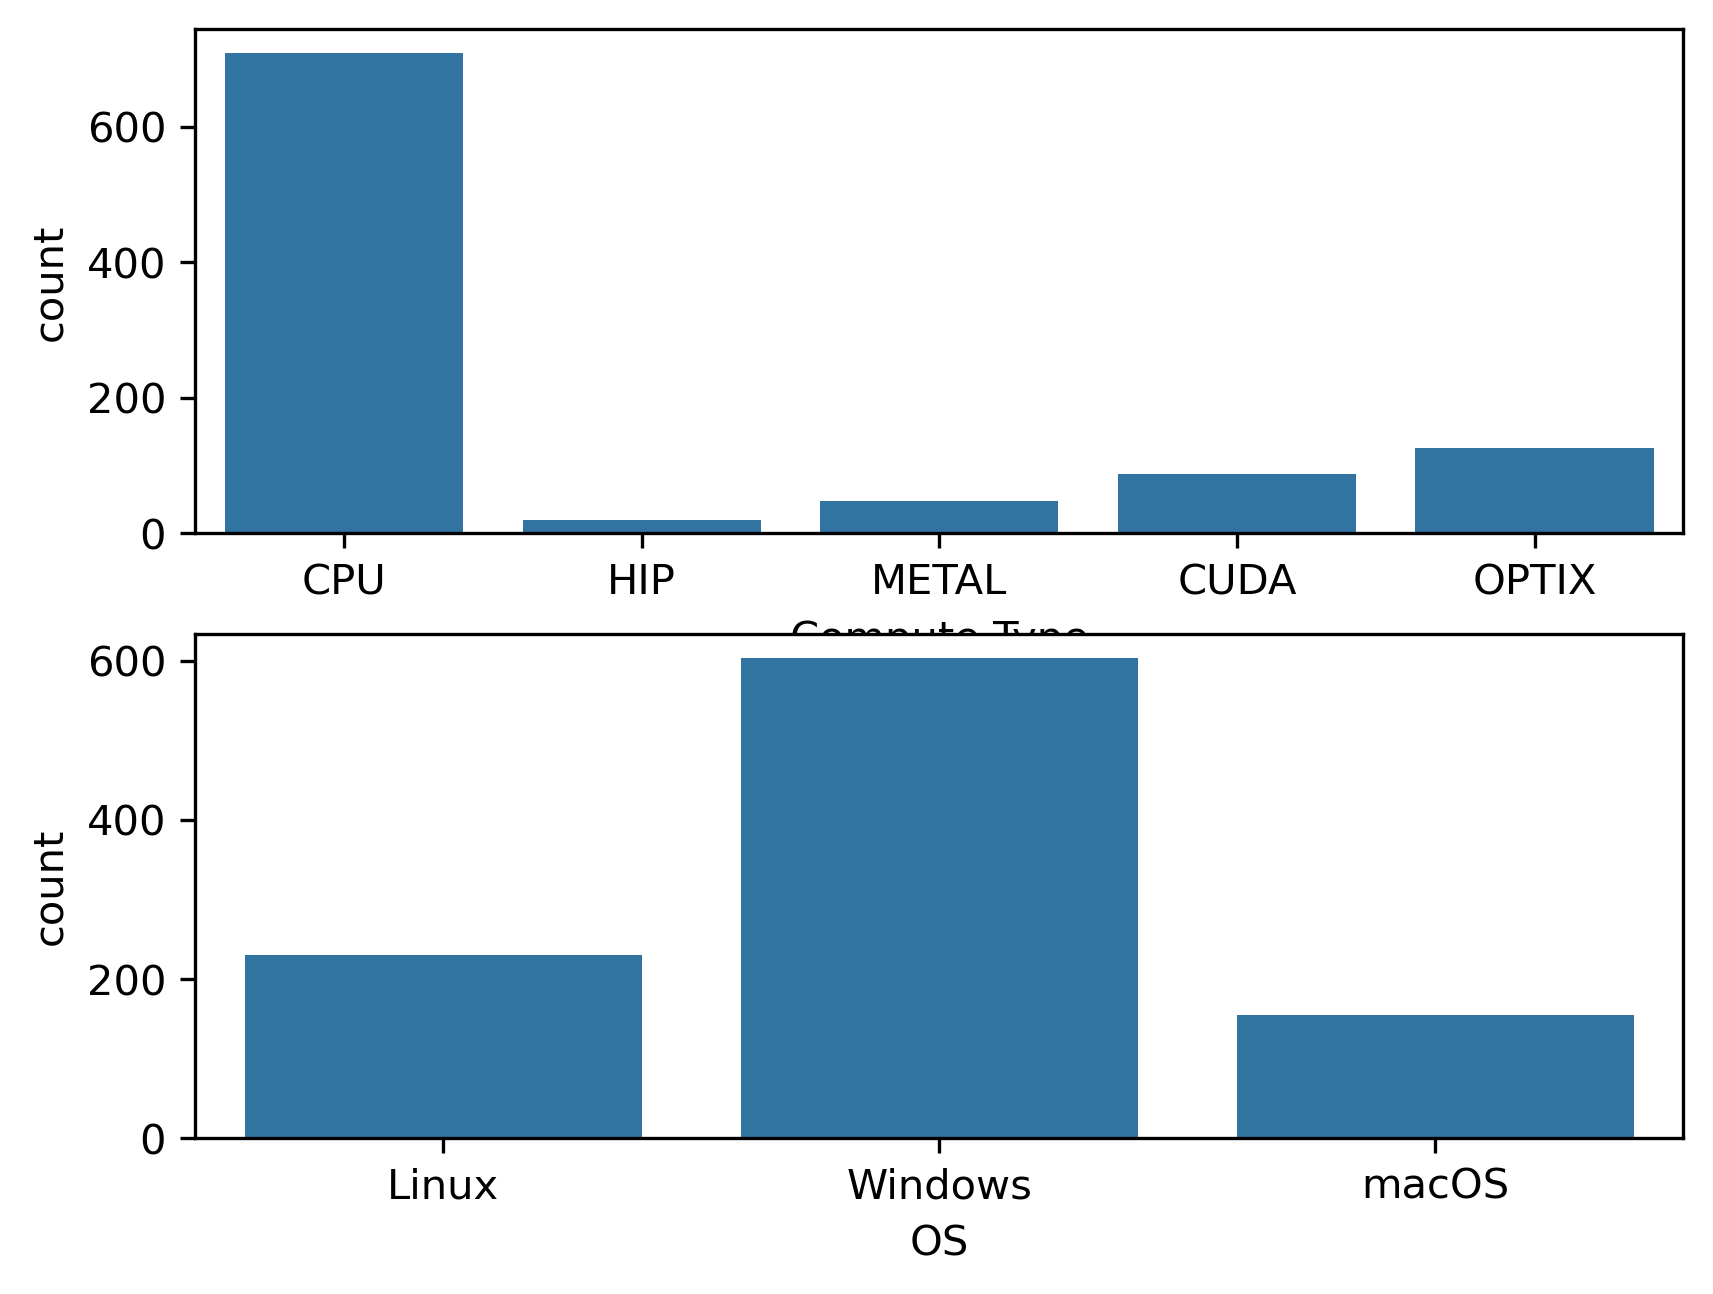

In [ ]:
# 변경할 컬럼 범주 별 분포 확인 시각화
fig, ax = plt.subplots(nrows=2)
# 2개의 subplot(세로 방향)을 갖는 figure 및 axes 객체를 생성함
# 각각의 subplot에 다른 범주형 변수의 분포를 시각화하기 위한 공간을 미리 할당함

# Compute Type 컬럼 범주 별 분포
sns.countplot(x="Compute Type", data=df, ax=ax[0])
# 'Compute Type' 컬럼에 존재하는 각 범주의 개수를 막대 그래프로 시각화함
# CPU, GPU, 기타 컴퓨팅 장치 타입별 데이터 개수를 직관적으로 확인할 수 있음
# ax[0]에 그래프를 그려 첫 번째 subplot에 해당 내용을 출력함

# OS 컬럼 범주 별 분포
sns.countplot(x="OS", data=df, ax=ax[1])
# 'OS' 컬럼에 존재하는 운영체제 종류별 개수를 막대 그래프로 시각화함
# Windows, Linux, 기타 OS 별로 벤치마크 데이터가 얼마나 분포되어 있는지를 시각적으로 확인함
# ax[1]에 그래프를 그려 두 번째 subplot에 해당 내용을 출력함

plt.show()
# 앞에서 설정한 두 개의 subplot을 포함한 전체 figure를 출력함
# 각 범주형 변수의 데이터 분포를 비교하거나, 후속 전처리(예: 이진화, 통합) 여부를 결정하는 데 활용됨


### 📌 `pd.get_dummies(df)`의 역할

`pd.get_dummies(df)`는 **pandas 라이브러리**에서 제공하는 함수로, **범주형 변수(categorical variable)**를 **수치형 변수(numerical variable)**로 변환하는 작업을 수행함.

이 과정을 **원-핫 인코딩(One-Hot Encoding)** 또는 **가변수 처리(dummy variable encoding)**라고 부르며, **기계학습 모델이 범주형 변수를 해석할 수 있도록 변환**하는 데 필수적인 전처리 과정임.

---

### 🔄 작동 단계 설명

### 1. **범주형 변수 자동 탐지 단계**

- 문자열(string), 범주형(object/category) 자료형을 갖는 컬럼을 자동으로 식별함
- 수치형(float, int 등) 컬럼은 그대로 유지함
- 다만, 명시적으로 `columns` 인자를 지정하지 않으면 모든 object형 또는 category형 컬럼이 변환 대상이 됨

### 2. **범주형 값 → 새로운 컬럼 생성 단계**

- 각 범주형 컬럼에 대해 고유한 값(unique value)을 기준으로 새로운 열(column)을 생성함
- 예를 들어, `OS` 컬럼이 `['Windows', 'Linux']`로 구성되어 있다면, `OS_Windows`, `OS_Linux`라는 새로운 열이 생성됨

### 3. **이진 표시 단계 (0 또는 1)**

- 각 관측값이 해당 범주에 속하면 `1`, 속하지 않으면 `0`으로 표시함
- 이렇게 생성된 열은 이진 변수(binary variable)의 형태를 가지며, 머신러닝 모델 입력에 적합한 형태가 됨

### 4. **원본 범주형 컬럼 제거 및 변환된 열 결합 단계**

- 변환 대상이 된 범주형 컬럼은 제거되고, 새롭게 생성된 열이 기존 데이터프레임에 결합됨
- 결과적으로 모든 값이 수치형(float 또는 int)으로 구성된 새로운 데이터프레임이 생성됨

---

### ✅ 예시 비교 (간단한 예제)

### 원본 데이터프레임

| ID | OS |
| --- | --- |
| 1 | Windows |
| 2 | Linux |
| 3 | Windows |

### `pd.get_dummies(df)` 결과

| ID | OS_Linux | OS_Windows |
| --- | --- | --- |
| 1 | 0 | 1 |
| 2 | 1 | 0 |
| 3 | 0 | 1 |

---

### ⚠️ 주의 사항

- `drop_first=True` 옵션을 사용하면 다중공선성(multicollinearity)을 방지하기 위해 첫 범주를 제거함 (예: `OS_Linux`만 남김)
- 고유값이 지나치게 많은 컬럼(예: ID, 이름 등)은 원-핫 인코딩 시 열이 과도하게 생성되어 희소행렬이 될 위험이 있으므로 사전에 필터링이 필요함

In [ ]:
# 전체 컬럼 일괄 가변수 처리
df1 = pd.get_dummies(df)
# df 데이터프레임의 모든 범주형 변수에 대해 one-hot encoding(가변수 처리)을 수행함
# 각 범주형 변수의 고유한 값들을 새로운 열로 분리하고, 해당 범주에 속하는 경우 1, 아니면 0으로 표시함
# 모델 학습을 위해 범주형 데이터를 수치형으로 변환하는 전처리 작업임

df1.head()
# 가변수 처리된 df1 데이터프레임의 상위 5개 행을 출력함
# 변환이 정상적으로 이루어졌는지 확인하고, 생성된 새로운 열들의 이름과 구조를 점검하는 단계임


,Median Score,Device Name_12X Intel Xeon CPU E5-2450 0 @ 2.10GHz,Device Name_24X Intel Xeon CPU E5-2690 v3 @ 2.60GHz,Device Name_2X 12th Gen Intel Core i9-12900KF,Device Name_2X AMD EPYC 7343 16-Core Processor,Device Name_2X AMD Opteron Processor 6276,Device Name_2X AMD Opteron(tm) Processor 6328,Device Name_2X AMD Ryzen Threadripper PRO 3995WX 64-Cores,Device Name_2X Genuine Intel CPU 0000 @ 2.00GHz,Device Name_2X Genuine Intel CPU 0000 @ 2.10GHz,...,Device Name_T500,Device Name_Virtual CPU @ 2.99GHz,Compute Type_CPU,Compute Type_CUDA,Compute Type_HIP,Compute Type_METAL,Compute Type_OPTIX,OS_Linux,OS_Windows,OS_macOS
0,78.570,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
1,297.940,False,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
2,424.470,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
3,439.210,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
4,81.478,False,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False


In [23]:
df1.shape

(1006, 740)

In [ ]:
# 특정 컬럼만 가변수 처리
df2 = pd.get_dummies(df, columns=['Compute Type', 'OS'])
# 'Compute Type'과 'OS' 컬럼에 대해서만 one-hot encoding(가변수 처리)을 수행함
# 선택한 두 컬럼의 각 범주값에 대해 새로운 열을 생성하고, 해당 범주일 경우 1, 아닐 경우 0으로 표시함
# 원본 컬럼은 제거되고, 그에 대응하는 이진 컬럼들로 대체됨
# 나머지 컬럼들은 원본 그대로 유지되므로, 필요 컬럼만 선택적으로 변환할 때 유용함

df2.head()
# 가변수 처리된 df2 데이터프레임의 상위 5개 행을 출력함
# 지정한 두 범주형 컬럼이 각각 여러 개의 이진 컬럼으로 분해되었는지 확인하는 단계임


,Device Name,Median Score,Compute Type_CPU,Compute Type_CUDA,Compute Type_HIP,Compute Type_METAL,Compute Type_OPTIX,OS_Linux,OS_Windows,OS_macOS
0,12X Intel Xeon CPU E5-2450 0 @ 2.10GHz,78.570,True,False,False,False,False,True,False,False
1,24X Intel Xeon CPU E5-2690 v3 @ 2.60GHz,297.940,True,False,False,False,False,False,True,False
2,2X 12th Gen Intel Core i9-12900KF,424.470,True,False,False,False,False,False,True,False
3,2X AMD EPYC 7343 16-Core Processor,439.210,True,False,False,False,False,True,False,False
4,2X AMD Opteron Processor 6276,81.478,True,False,False,False,False,False,True,False


In [24]:
df2.shape

(1006, 10)

In [ ]:
# 하나의 가변수 범주 제거 옵션 적용
df3 = pd.get_dummies(df, columns=['Compute Type', 'OS'], drop_first=True)
# 'Compute Type'과 'OS' 컬럼에 대해 one-hot encoding을 수행하되, 각 컬럼의 첫 번째 범주는 제거함
# drop_first=True 옵션을 사용하면 n개의 범주 중 (n-1)개의 가변수만 생성되어 기준 범주는 제외됨
# 이는 다중공선성(multicollinearity) 문제를 방지하고, 회귀 모델 등에서 수학적으로 안정적인 해석을 가능하게 함
# 예: 'Compute Type'에 'CPU', 'GPU'가 있으면 'Compute Type_GPU'만 남고, 'CPU'는 기본값(0)으로 해석됨

df3.head()
# 가변수 처리 후 불필요한 기준 컬럼을 제거한 df3의 상위 5개 행을 출력함
# 컬럼명이 의도대로 생성되었는지, 데이터 변환이 정확하게 수행되었는지 확인하는 과정임


,Device Name,Median Score,Compute Type_CUDA,Compute Type_HIP,Compute Type_METAL,Compute Type_OPTIX,OS_Windows,OS_macOS
0,12X Intel Xeon CPU E5-2450 0 @ 2.10GHz,78.570,False,False,False,False,False,False
1,24X Intel Xeon CPU E5-2690 v3 @ 2.60GHz,297.940,False,False,False,False,True,False
2,2X 12th Gen Intel Core i9-12900KF,424.470,False,False,False,False,True,False
3,2X AMD EPYC 7343 16-Core Processor,439.210,False,False,False,False,False,False
4,2X AMD Opteron Processor 6276,81.478,False,False,False,False,True,False


In [27]:
df3.shape

(1006, 8)

In [ ]:
# 결측값을 별도의 컬럼으로 처리 옵션 적용
df4 = pd.get_dummies(df, columns=['Compute Type', 'OS'], 
                     drop_first=True, dummy_na=True)
# 'Compute Type'과 'OS' 컬럼에 대해 one-hot encoding을 수행함
# drop_first=True 옵션을 사용하여 각 범주형 변수에서 첫 번째 범주는 제거함 (기준값 처리 목적)
# dummy_na=True 옵션을 추가하면 결측값(NaN)을 하나의 별도 범주로 간주하여 '_nan'이라는 이름의 이진 컬럼을 생성함
# 결측값을 삭제하거나 대체하지 않고 모델에 그대로 포함시키고 싶을 때 유용함

df4.head()
# 가변수 처리 및 결측값 처리 후 생성된 df4의 상위 5개 행을 출력함
# '_nan' 컬럼이 생성되었는지, 각 컬럼 변환이 의도대로 작동했는지 확인하는 단계임


,Device Name,Median Score,Compute Type_CUDA,Compute Type_HIP,Compute Type_METAL,Compute Type_OPTIX,Compute Type_nan,OS_Windows,OS_macOS,OS_nan
0,12X Intel Xeon CPU E5-2450 0 @ 2.10GHz,78.570,False,False,False,False,False,False,False,False
1,24X Intel Xeon CPU E5-2690 v3 @ 2.60GHz,297.940,False,False,False,False,False,True,False,False
2,2X 12th Gen Intel Core i9-12900KF,424.470,False,False,False,False,False,True,False,False
3,2X AMD EPYC 7343 16-Core Processor,439.210,False,False,False,False,False,False,False,False
4,2X AMD Opteron Processor 6276,81.478,False,False,False,False,False,True,False,False
